### Data Visualization using Matplotlib & Seaborn

Data Visualization is the process of presenting data graphically. It helps us understand patterns, trends, distributions, and relationships within the data.

In this notebook, we will learn how to create different types of charts using Matplotlib and Seaborn. The focus of this notebook is on creating and customizing visualizations.

> **Note:** The interpretation and analysis of these charts will be covered in the next notebook: *Exploratory Data Analysis (EDA) for Machine Learning*.

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply Seaborn Theme
sns.set_theme(style="whitegrid")

In [2]:
# Load the Dataset
df = pd.read_csv("../datasets/student_performance_cleaned.csv")

> MatplotLib

| Chart        | Why ML Students Need It               |
| ------------ | ------------------------------------- |
| Histogram    | Understand feature distribution       |
| Scatter Plot | Analyze relationships                 |
| Box Plot     | Detect outliers                       |
| Bar Chart    | Analyze categorical variables         |
| Line Plot    | Time-series data (basic introduction) |


> Searborn

| Chart           | Why ML Students Need It                                 |
| --------------- | ------------------------------------------------------- |
| `countplot()`   | Class distribution                                      |
| `histplot()`    | Better distribution visualization                       |
| `boxplot()`     | Outlier analysis                                        |
| `scatterplot()` | Feature relationships                                   |
| `pairplot()`    | Explore relationships among multiple numerical features |
| `heatmap()`     | Correlation matrix visualization                        |


>

# Matplotlib
### Line Chart
> Purpose
> - Display trends or changes in data over an ordered sequence.

> Method-1

In [3]:
# Set Admission data as date
df['admission_date']= pd.to_datetime(df["admission_date"],errors="coerce")

In [4]:
df.dtypes

student_id                        int64
full_name                           str
gender                              str
age                               int64
department                          str
semester                          int64
marks                             int64
attendance_percentage           float64
city                                str
admission_date           datetime64[us]
email                               str
scholarship                         str
tuition_fee                     float64
dtype: object

In [5]:
# # Extract Month Number
df["Month"] = df["admission_date"].dt.month

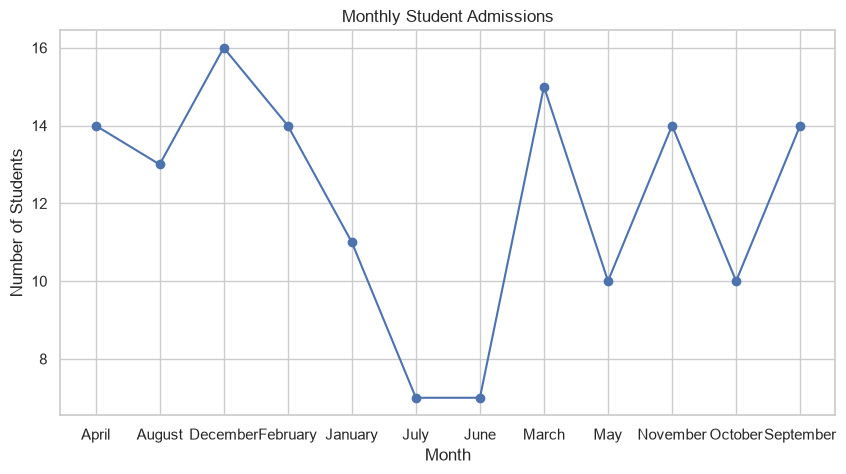

In [6]:
# Extract Month Name
df["month"] = df["admission_date"].dt.month_name()

# Count admissions by month
monthly_admissions = df["month"].value_counts().sort_index()

# Create Line Plot
plt.figure(figsize=(10,5))

plt.plot(monthly_admissions.index,
         monthly_admissions.values,
         marker="o")

plt.title("Monthly Student Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Students")

plt.grid(True)

plt.show()

> Method-2

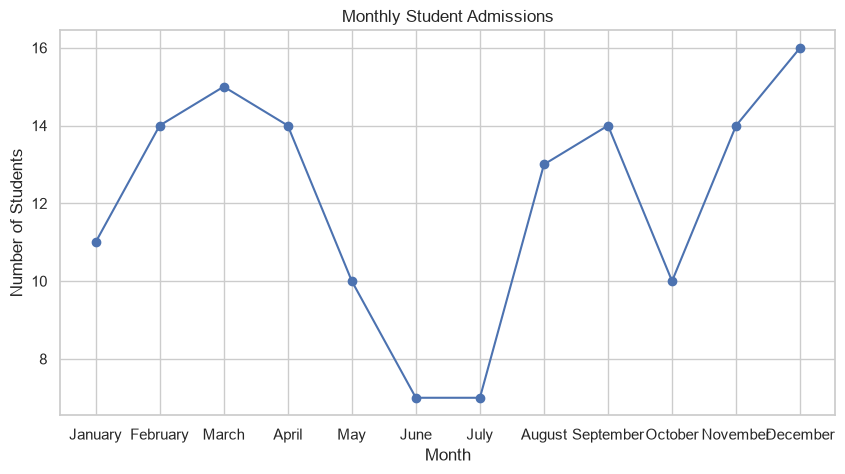

In [7]:
# Extract Month Number
df["month_number"] = df["admission_date"].dt.month

# Extract Month Name
df["month_name"] = df["admission_date"].dt.month_name()

# Count Admissions by Month
monthly_admissions = (
    df.groupby(["month_number", "month_name"])
      .size()
      .reset_index(name="Admissions")     # reset_index() converts the index into normal columns.
                                          # name="Admissions" assigns a meaningful name to the column created by groupby().size().
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_admissions["month_name"],
    monthly_admissions["Admissions"],
    marker="o"
)

plt.title("Monthly Student Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Students")

plt.grid(True)

plt.show()

> Method-3

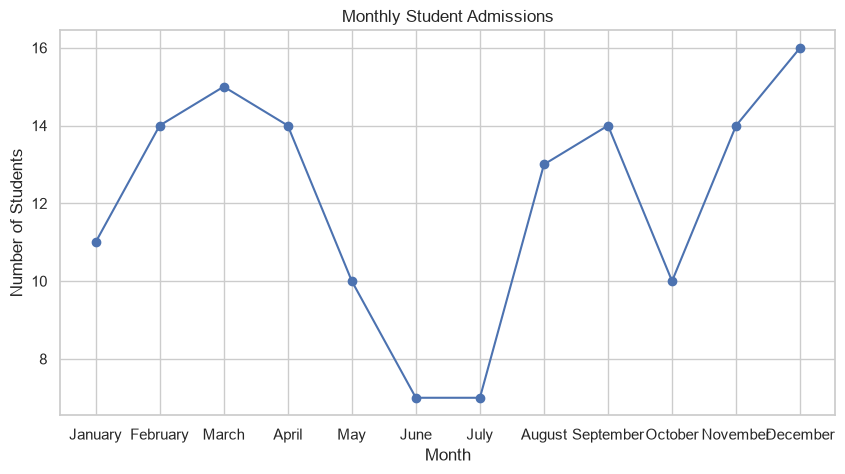

In [8]:
monthly_admissions = (
    df.groupby(df["admission_date"].dt.month_name())
      .size()
      .reindex([
          "January",
          "February",
          "March",
          "April",
          "May",
          "June",
          "July",
          "August",
          "September",
          "October",
          "November",
          "December"
      ])
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_admissions.index,
    monthly_admissions.values,
    marker="o"
)

plt.title("Monthly Student Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Students")

plt.grid(True)

plt.show()

### Create Bar Chart
> Purpose
> - Compare values across different categories.

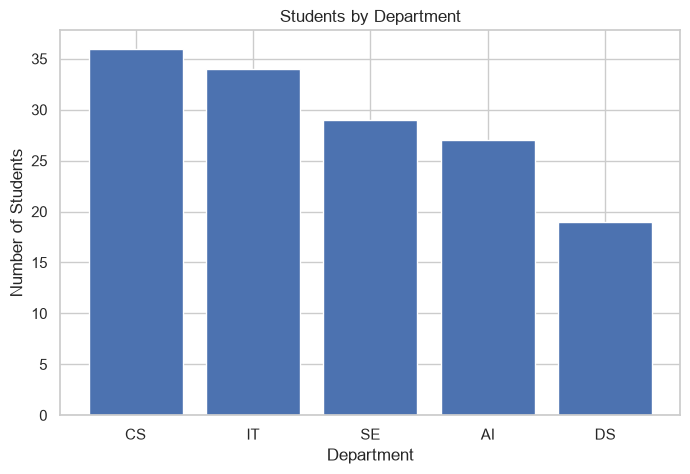

In [9]:
# Create a Bar Chart

department_counts = df["department"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(department_counts.index,
        department_counts.values)

plt.title("Students by Department")
plt.xlabel("Department")
plt.ylabel("Number of Students")

plt.show()

### Create Histogram
> Purpose
> - Display the distribution of a numerical feature.

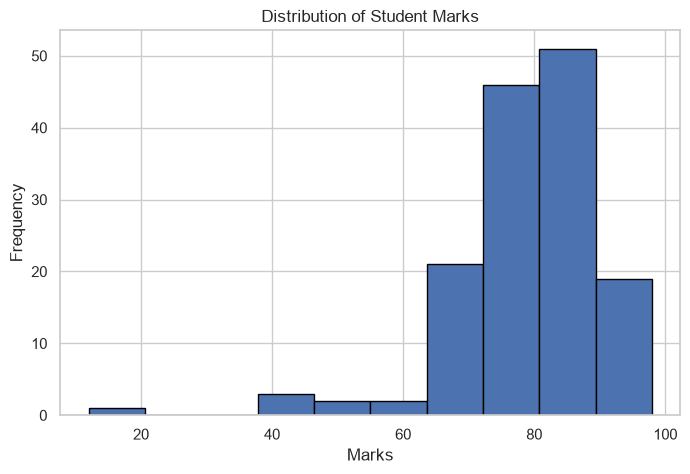

In [10]:
# Create a Histogram

plt.figure(figsize=(8,5))

plt.hist(df["marks"],
         bins=10,
         edgecolor="black")

plt.title("Distribution of Student Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.show()

### Create Scatter Plot
> Purpose
> - Display the relationship between two numerical variables.

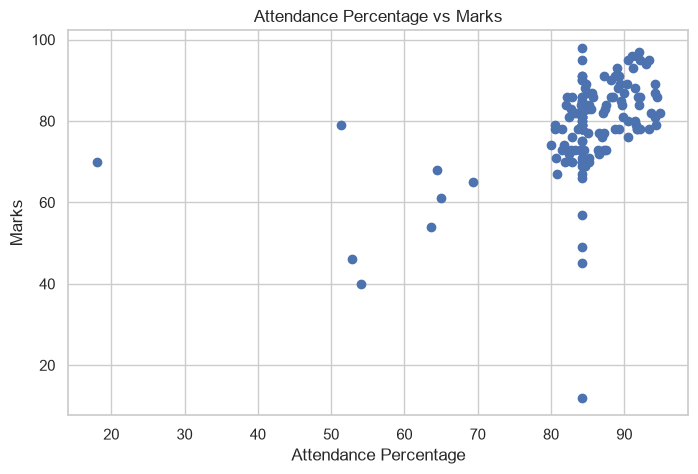

In [11]:
# Create a Scatter Plot

plt.figure(figsize=(8,5))

plt.scatter(df["attendance_percentage"],
            df["marks"])

plt.title("Attendance Percentage vs Marks")
plt.xlabel("Attendance Percentage")
plt.ylabel("Marks")

plt.show()

### Create Box Plot
> Purpose
> - Summarize the distribution of numerical data and identify possible outliers.

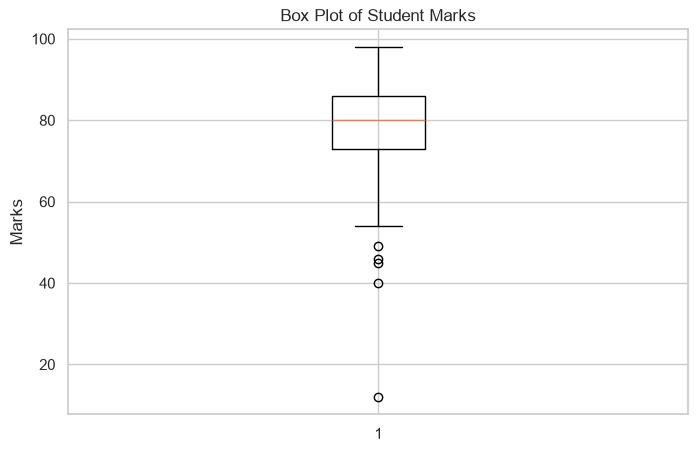

In [12]:
# Create a Box Plot

plt.figure(figsize=(8,5))

plt.boxplot(df["marks"])

plt.title("Box Plot of Student Marks")
plt.ylabel("Marks")

plt.show()

### Create Pie Chart
> Purpose
> - Display the proportion of each category in the dataset.

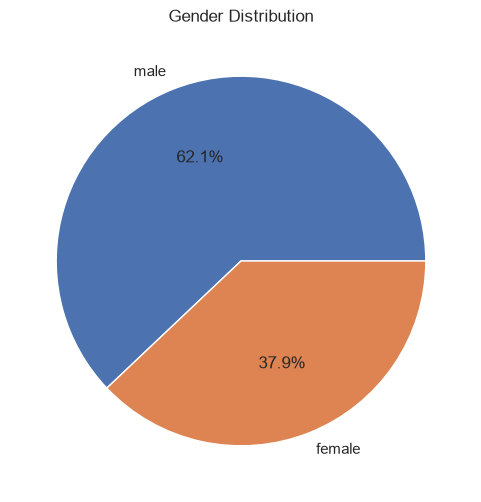

In [13]:
# Create a Pie Chart

gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(gender_counts.values,
        labels=gender_counts.index,
        autopct="%1.1f%%")

plt.title("Gender Distribution")

plt.show()

# Seaborn

### Create Count Plot - Column Chart
> Purpose
> - Display the number of observations in each category.

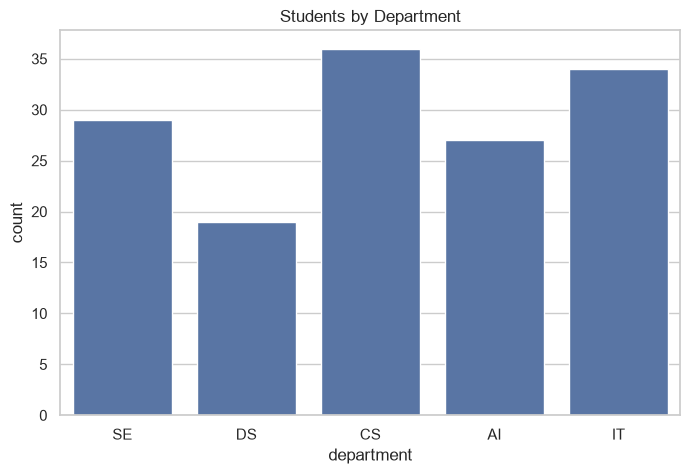

In [14]:
# Create a Count Plot

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="department")

plt.title("Students by Department")

plt.show()

### Create Hist Plot
> Purpose
> - Display the distribution of a numerical feature using Seaborn.

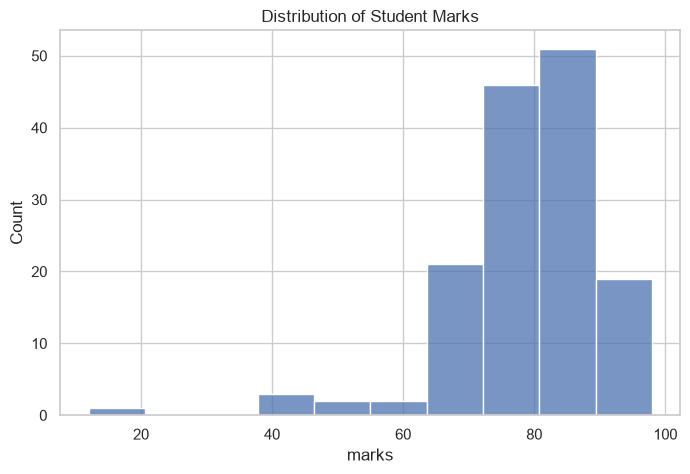

In [15]:
# Create a Histplot

plt.figure(figsize=(8,5))

sns.histplot(df["marks"],
             bins=10)

plt.title("Distribution of Student Marks")

plt.show()

### Scatter Plot
> Purpose
> - Display the relationship between two numerical variables using Seaborn.

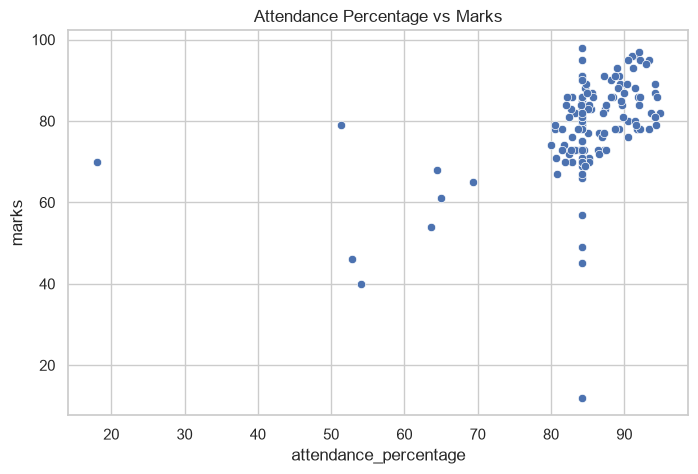

In [16]:
# Create a Scatterplot

plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x="attendance_percentage",
                y="marks")

plt.title("Attendance Percentage vs Marks")

plt.show()

### Box Plot
> Purpose
> - Display the spread of numerical data and identify possible outliers.

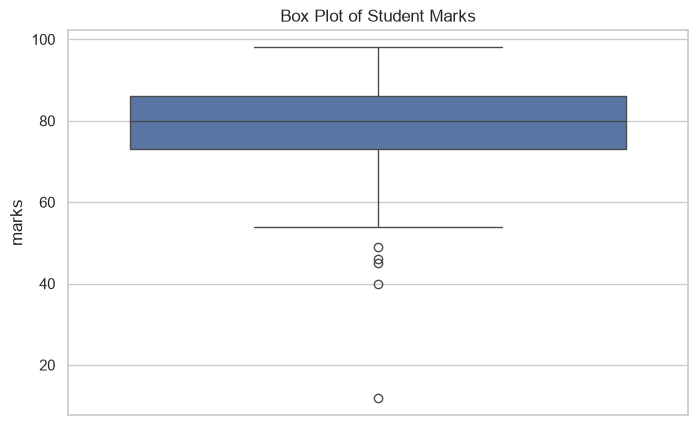

In [17]:
# Create a Boxplot

plt.figure(figsize=(8,5))

sns.boxplot(y=df["marks"])

plt.title("Box Plot of Student Marks")

plt.show()

### Heatmap
> Purpose
> - Visualize the correlation between numerical features.

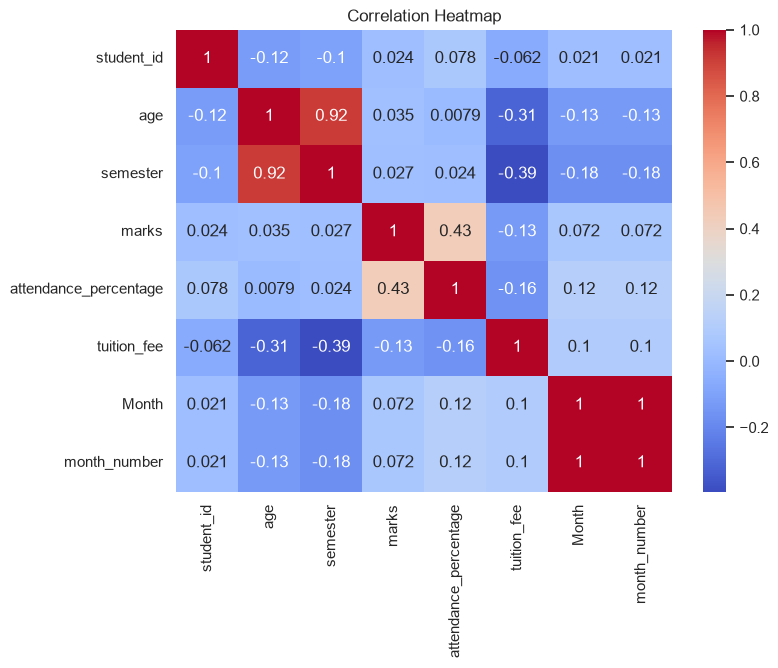

In [18]:
# Create a Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Pairplot
> Purpose
> - Display pairwise relationships between multiple numerical features.

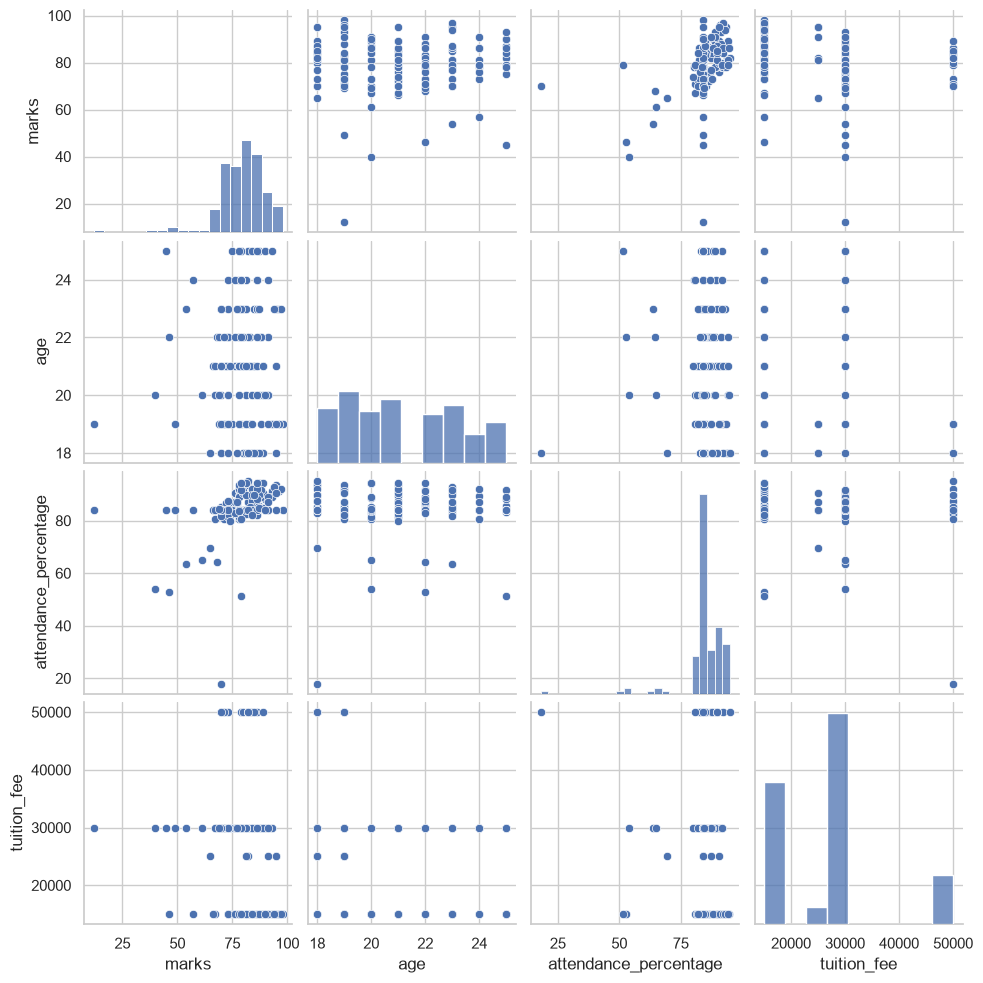

In [19]:
# Create a Pairplot

sns.pairplot(df[["marks",
                 "age",
                 "attendance_percentage",
                 "tuition_fee"]])

plt.show()

## Summary

In this notebook, we learned how to create various charts using Matplotlib and Seaborn.

The charts covered include:

- Line Plot
- Bar Chart
- Histogram
- Scatter Plot
- Box Plot
- Pie Chart
- Count Plot
- Histplot
- Scatterplot
- Boxplot
- Heatmap
- Pairplot

These visualizations will be used in the next notebook to perform Exploratory Data Analysis (EDA) and Relationship Analysis for Machine Learning.